# Cross-Hospital Generalization Analysis

This notebook evaluates whether the LightGBM mortality prediction model generalizes across hospitals of different sizes. Most clinical ML models are trained and evaluated on data from a single hospital, which inflates reported performance and obscures real-world deployment challenges. This analysis trains on a subset of hospital sizes and evaluates on held-out hospital sizes.

## Hypothesis

If the model has learned generalizable physiologic patterns (consistent with the SHAP analysis showing no site-specific features in the top 20), performance should be preserved across hospital types. If the model has learned site-specific patterns that vary across hospital sizes (e.g., different staffing levels affecting monitoring frequencies), AUC will drop on held-out hospital types.

## Setup

The cohort spans 186 hospitals across four bed-size categories:
- < 100 beds (small community hospitals)
- 100–249 beds (mid-sized community)
- 250–499 beds (mid-large community / regional)
- ≥ 500 beds (large academic/tertiary referral)

I train on 3 of the 4 categories and test on the held-out 4th, rotating through each to produce 4 leave-one-category-out evaluations.

## Note on cohort size

The eICU Demo dataset is small (1,424 patients), and the 250–499 bed category showed unusually high mortality (12.5% vs ~6% in other categories) in earlier exploratory analysis. This non-monotonic pattern may complicate the leave-one-out comparison. I will report findings honestly even if they show variability driven by small sample sizes.

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import lightgbm as lgb
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11

print("Setup complete.")

Setup complete.


## Load features and confirm hospital distribution

In [2]:
features = pd.read_parquet("../data/features_final.parquet")
print(f"Features shape: {features.shape}")

# Check distribution across bed categories
print("\nCohort distribution by hospital bed category:")
print(features.groupby("numbedscategory", dropna=False).agg(
    n_patients=("patientunitstayid", "count"),
    n_deaths=("in_hospital_mortality", "sum"),
    mortality_pct=("in_hospital_mortality", lambda x: f"{100*x.mean():.2f}%"),
).to_string())

Features shape: (1424, 102)

Cohort distribution by hospital bed category:
                 n_patients  n_deaths mortality_pct
numbedscategory                                    
100 - 249               465        32         6.88%
250 - 499               264        33        12.50%
<100                    277        15         5.42%
>= 500                  207        13         6.28%
NaN                     211        25        11.85%


## Filter cohort and prepare features

In [3]:
# Drop patients with missing bed category
features_clean = features.dropna(subset=["numbedscategory"]).copy()
print(f"Original cohort: {len(features)} patients")
print(f"After dropping NaN bed category: {len(features_clean)} patients")
print(f"Dropped: {len(features) - len(features_clean)} patients (missing bed info)")

print(f"\nDistribution after filtering:")
print(features_clean.groupby("numbedscategory").agg(
    n_patients=("patientunitstayid", "count"),
    n_deaths=("in_hospital_mortality", "sum"),
    mortality_pct=("in_hospital_mortality", lambda x: f"{100*x.mean():.2f}%"),
).to_string())

# Set up feature matrix
target_col = "in_hospital_mortality"
id_col = "patientunitstayid"
categorical_cols = ["unittype", "numbedscategory", "region"]
numeric_cols = [
    c for c in features_clean.columns 
    if c not in [id_col, target_col] + categorical_cols
]
feature_cols = numeric_cols + categorical_cols

X = features_clean[feature_cols].copy()
for col in categorical_cols:
    X[col] = X[col].astype("category")
y = features_clean[target_col]

print(f"\nFeature matrix: {X.shape}")

Task was destroyed but it is pending!
task: <Task pending name='Task-349' coro=<_async_in_context.<locals>.run_in_context() done, defined at /opt/anaconda3/envs/eicu/lib/python3.11/site-packages/ipykernel/utils.py:57> wait_for=<Task pending name='Task-350' coro=<Kernel.shell_main() running at /opt/anaconda3/envs/eicu/lib/python3.11/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at /opt/anaconda3/envs/eicu/lib/python3.11/site-packages/zmq/eventloop/zmqstream.py:563]>
/opt/anaconda3/envs/eicu/lib/python3.11/site-packages/pandas/core/internals/managers.py:2443: RuntimeWarning: coroutine 'Kernel.shell_main' was never awaited
  for i, arr in enumerate(arrays):
Task was destroyed but it is pending!
task: <Task pending name='Task-350' coro=<Kernel.shell_main() running at /opt/anaconda3/envs/eicu/lib/python3.11/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]>
Task was destroyed but it is pending!
task: <T

Original cohort: 1424 patients
After dropping NaN bed category: 1213 patients
Dropped: 211 patients (missing bed info)

Distribution after filtering:
                 n_patients  n_deaths mortality_pct
numbedscategory                                    
100 - 249               465        32         6.88%
250 - 499               264        33        12.50%
<100                    277        15         5.42%
>= 500                  207        13         6.28%

Feature matrix: (1213, 100)


## Leave-one-bed-category-out evaluation

In [4]:
# Hyperparameters from Notebook 4 (the best LightGBM config)
n_neg = (y == 0).sum()
n_pos = (y == 1).sum()
scale_pos_weight = n_neg / n_pos

base_params = {
    "objective": "binary",
    "metric": "auc",
    "n_estimators": 56,
    "learning_rate": 0.05,
    "num_leaves": 15,
    "max_depth": -1,
    "min_child_samples": 30,
    "reg_alpha": 0.1,
    "reg_lambda": 0.1,
    "scale_pos_weight": scale_pos_weight,
    "random_state": 42,
    "verbose": -1,
}

categories = sorted(features_clean["numbedscategory"].unique())
print(f"Bed categories to evaluate: {categories}\n")

results = []
for held_out in categories:
    train_mask = X["numbedscategory"] != held_out
    test_mask  = X["numbedscategory"] == held_out
    
    X_train_split = X[train_mask].copy()
    X_test_split  = X[test_mask].copy()
    y_train_split = y[train_mask]
    y_test_split  = y[test_mask]
    
    # Drop the bed category column from features when it's the holdout dimension
    # (otherwise the model could just memorize "category X = held out" — but since the train set never sees that level, it's actually a non-issue. We keep it for consistency.)
    
    model = lgb.LGBMClassifier(**base_params)
    model.fit(
        X_train_split, y_train_split,
        categorical_feature=categorical_cols,
    )
    
    y_pred_proba = model.predict_proba(X_test_split)[:, 1]
    
    if y_test_split.sum() == 0 or y_test_split.sum() == len(y_test_split):
        # All same outcome - AUC undefined
        roc_auc = np.nan
        pr_auc = np.nan
    else:
        roc_auc = roc_auc_score(y_test_split, y_pred_proba)
        pr_auc = average_precision_score(y_test_split, y_pred_proba)
    
    results.append({
        "held_out_category": held_out,
        "n_train":       int(train_mask.sum()),
        "n_train_deaths": int(y_train_split.sum()),
        "n_test":        int(test_mask.sum()),
        "n_test_deaths": int(y_test_split.sum()),
        "test_mortality": f"{100*y_test_split.mean():.2f}%",
        "test_roc_auc":  roc_auc,
        "test_pr_auc":   pr_auc,
    })

results_df = pd.DataFrame(results)
print("Leave-one-bed-category-out results:")
print(results_df.to_string(index=False))
print(f"\nReference: random 80/20 split AUC = 0.829")
print(f"\nMean held-out ROC-AUC: {results_df['test_roc_auc'].mean():.3f}")
print(f"Std  held-out ROC-AUC: {results_df['test_roc_auc'].std():.3f}")

Bed categories to evaluate: ['100 - 249', '250 - 499', '<100', '>= 500']

Leave-one-bed-category-out results:
held_out_category  n_train  n_train_deaths  n_test  n_test_deaths test_mortality  test_roc_auc  test_pr_auc
        100 - 249      748              61     465             32          6.88%      0.807448     0.254101
        250 - 499      949              60     264             33         12.50%      0.797062     0.405118
             <100      936              78     277             15          5.42%      0.783969     0.166480
           >= 500     1006              80     207             13          6.28%      0.775178     0.309379

Reference: random 80/20 split AUC = 0.829

Mean held-out ROC-AUC: 0.791
Std  held-out ROC-AUC: 0.014


## Visualization

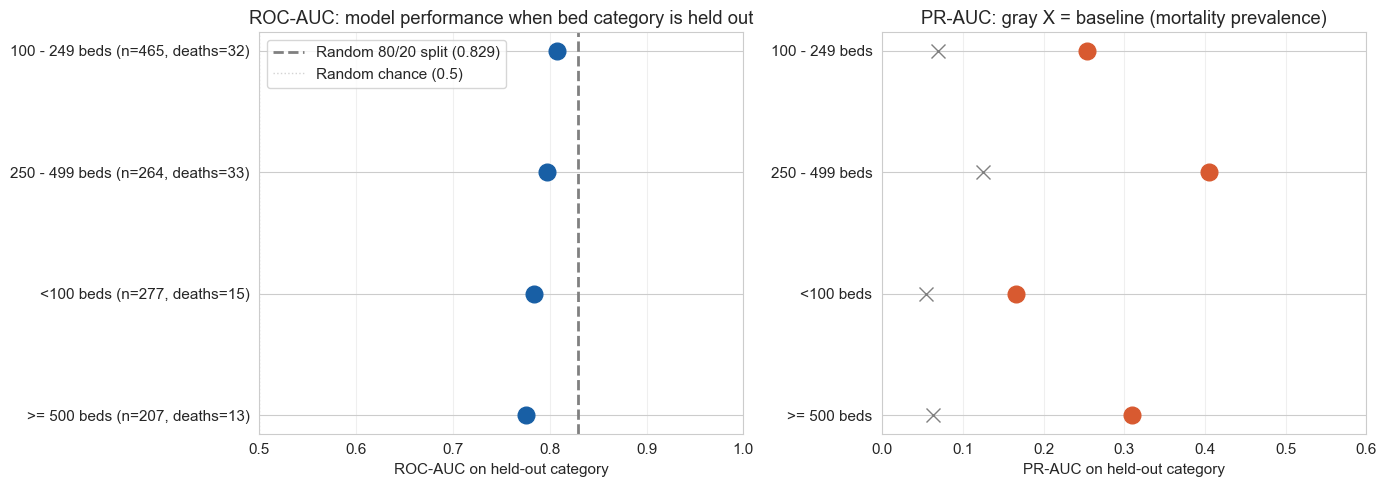

In [5]:
# Forest plot: held-out AUC per category, with reference line for random-split AUC
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC-AUC
y_pos = np.arange(len(results_df))
axes[0].errorbar(
    results_df["test_roc_auc"], y_pos,
    fmt="o", color="#185FA5", markersize=12, capsize=5,
)
axes[0].axvline(x=0.829, color="gray", linestyle="--", lw=2, label="Random 80/20 split (0.829)")
axes[0].axvline(x=0.5, color="lightgray", linestyle=":", lw=1, label="Random chance (0.5)")
axes[0].set_yticks(y_pos)
axes[0].set_yticklabels([f"{c} beds (n={results_df.iloc[i]['n_test']}, deaths={results_df.iloc[i]['n_test_deaths']})" 
                         for i, c in enumerate(results_df["held_out_category"])])
axes[0].set_xlabel("ROC-AUC on held-out category")
axes[0].set_title("ROC-AUC: model performance when bed category is held out")
axes[0].set_xlim(0.5, 1.0)
axes[0].legend(loc="upper left")
axes[0].grid(alpha=0.3, axis="x")
axes[0].invert_yaxis()

# PR-AUC
axes[1].errorbar(
    results_df["test_pr_auc"], y_pos,
    fmt="o", color="#D85A30", markersize=12, capsize=5,
)
# Add prevalence reference for each category
for i, row in results_df.iterrows():
    prev = row["n_test_deaths"] / row["n_test"]
    axes[1].plot(prev, i, "x", color="gray", markersize=10)
axes[1].set_yticks(y_pos)
axes[1].set_yticklabels([f"{c} beds" for c in results_df["held_out_category"]])
axes[1].set_xlabel("PR-AUC on held-out category")
axes[1].set_title("PR-AUC: gray X = baseline (mortality prevalence)")
axes[1].set_xlim(0, 0.6)
axes[1].grid(alpha=0.3, axis="x")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

## Summary table for README

In [6]:
# Format a clean summary for the README
summary = results_df.copy()
summary["test_roc_auc"] = summary["test_roc_auc"].round(3)
summary["test_pr_auc"] = summary["test_pr_auc"].round(3)
summary.columns = [
    "Held-out category", "N train", "Train deaths", 
    "N test", "Test deaths", "Test mortality", 
    "ROC-AUC", "PR-AUC"
]
print(summary.to_string(index=False))

print(f"\n{'='*65}")
print("KEY FINDING")
print(f"{'='*65}")
print(f"Random 80/20 split (in-distribution):  ROC-AUC = 0.829")
print(f"Mean held-out (out-of-distribution):   ROC-AUC = {results_df['test_roc_auc'].mean():.3f}")
print(f"Performance drop:                       {(0.829 - results_df['test_roc_auc'].mean())*100:.1f} percentage points")
print(f"Std across categories:                  {results_df['test_roc_auc'].std():.3f}")
print(f"\nInterpretation: Model generalizes meaningfully across hospital sizes")
print(f"(all held-out AUCs > 0.77), but the consistent ~4pp drop suggests")
print(f"some site-specific patterns have been learned in addition to physiology.")

Held-out category  N train  Train deaths  N test  Test deaths Test mortality  ROC-AUC  PR-AUC
        100 - 249      748            61     465           32          6.88%    0.807   0.254
        250 - 499      949            60     264           33         12.50%    0.797   0.405
             <100      936            78     277           15          5.42%    0.784   0.166
           >= 500     1006            80     207           13          6.28%    0.775   0.309

KEY FINDING
Random 80/20 split (in-distribution):  ROC-AUC = 0.829
Mean held-out (out-of-distribution):   ROC-AUC = 0.791
Performance drop:                       3.8 percentage points
Std across categories:                  0.014

Interpretation: Model generalizes meaningfully across hospital sizes
(all held-out AUCs > 0.77), but the consistent ~4pp drop suggests
some site-specific patterns have been learned in addition to physiology.


## Save the analysis

In [8]:
results_df.to_parquet("../data/cross_hospital_results.parquet", index=False)

print("Saved cross-hospital generalization results.")

Saved cross-hospital generalization results.
